<a href="https://colab.research.google.com/github/Habibahalya/Deep-learning-lanjut/blob/main/Tugas_4_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Instalasi & Impor Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW # Corrected import statement for AdamW
from tqdm import tqdm
# Setup Device (GPU jika tersedia)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")

Menggunakan device: cuda


Pengumpulan Dataset (Pembuatan Data)

In [8]:
def generate_data():
    pos_templates = [
        "Produk ini sangat luar biasa dan membantu saya.",
        "Saya sangat senang dengan pelayanan yang diberikan.",
        "Kualitas barangnya jempolan, sangat direkomendasikan.",
        "Pengiriman cepat dan kurirnya sangat ramah.",
        "Pengalaman belanja yang sangat memuaskan di sini."
    ]
    neg_templates = [
        "Barang rusak saat sampai, saya sangat kecewa.",
        "Pelayanan buruk dan respon admin sangat lambat.",
        "Kualitas tidak sesuai dengan harga yang dibayar.",
        "Pengiriman sangat lama, hampir dua minggu.",
        "Saya menyesal membeli produk ini, tidak berguna."
    ]
    neu_templates = [
        "Paket sudah diterima dengan kondisi standar.",
        "Barang sampai sesuai dengan deskripsi produk.",
        "Harganya cukup kompetitif dibandingkan toko lain.",
        "Ukuran produk sedang, tidak terlalu besar atau kecil.",
        "Fungsi produk berjalan normal seperti biasa."
    ]

    # Generate 100 untuk masing-masing label
    train_data = []
    for _ in range(20): # 20 * 5 = 100 per kategori
        for t in pos_templates: train_data.append({"text": t, "label": 2}) # 2: Positif
        for t in neg_templates: train_data.append({"text": t, "label": 0}) # 0: Negatif
        for t in neu_templates: train_data.append({"text": t, "label": 1}) # 1: Netral

    # Generate 400 data pengujian tanpa label
    test_templates = pos_templates + neg_templates + neu_templates
    test_data = []
    for i in range(400):
        # Mengambil kalimat acak dari template untuk simulasi data baru
        text = np.random.choice(test_templates) + f" (Variasi {i})"
        test_data.append({"text": text})

    return pd.DataFrame(train_data), pd.DataFrame(test_data)

df_train, df_test = generate_data()

print("Statistik Data Pelatihan:")
print(df_train['label'].value_counts())
print(f"\nJumlah Data Pengujian: {len(df_test)}")


Statistik Data Pelatihan:
label
2    100
0    100
1    100
Name: count, dtype: int64

Jumlah Data Pengujian: 400


 Persiapan Model & Tokenizer

In [3]:
# Menggunakan 'indobenchmark/indobert-base-p1' untuk bahasa Indonesia
model_name = 'indobenchmark/indobert-base-p1'
tokenizer = BertTokenizer.from_pretrained(model_name)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item] if self.labels is not None else -1

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Proses Fine-Tuning (Sederhana)

In [5]:
# Membagi data latih untuk validasi
train_df, val_df = train_test_split(df_train, test_size=0.1, random_state=42)

def create_data_loader(df, tokenizer, max_len, batch_size, has_label=True):
    ds = SentimentDataset(
        texts=df.text.to_numpy(),
        labels=df.label.to_numpy() if has_label else None,
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(ds, batch_size=batch_size, num_workers=0)

BATCH_SIZE = 16
MAX_LEN = 128

train_loader = create_data_loader(train_df, tokenizer, MAX_LEN, BATCH_SIZE)
val_loader = create_data_loader(val_df, tokenizer, MAX_LEN, BATCH_SIZE)

model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

# Loop Pelatihan (1 Epoch untuk demonstrasi karena data kecil & template)
model.train()
for batch in train_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['label'].to(device)

    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

print("Pelatihan selesai.")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Pelatihan selesai.


Pelabelan Data Pengujian (400 Kalimat)

In [6]:
model.eval()
predictions = []
test_texts = df_test['text'].tolist()

print("Melakukan prediksi pada data pengujian...")
with torch.no_grad():
    for text in tqdm(test_texts):
        encoded_review = tokenizer.encode_plus(
            text,
            max_length=MAX_LEN,
            add_special_tokens=True,
            return_token_type_ids=False,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True
        )

        input_ids = encoded_review['input_ids'].to(device)
        attention_mask = encoded_review['attention_mask'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, prediction = torch.max(outputs.logits, dim=1)
        predictions.append(prediction.item())

# Memetakan kembali angka ke label teks
label_map = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
df_test['predicted_label'] = [label_map[p] for p in predictions]

# Tampilkan hasil 10 data pertama
print("\nHasil Pelabelan Data Pengujian (10 Sampel Pertama):")
print(df_test.head(10))


Melakukan prediksi pada data pengujian...


100%|██████████| 400/400 [00:04<00:00, 97.22it/s] 


Hasil Pelabelan Data Pengujian (10 Sampel Pertama):
                                                text predicted_label
0  Harganya cukup kompetitif dibandingkan toko la...          Netral
1  Barang rusak saat sampai, saya sangat kecewa. ...         Negatif
2  Harganya cukup kompetitif dibandingkan toko la...          Netral
3  Ukuran produk sedang, tidak terlalu besar atau...          Netral
4  Kualitas tidak sesuai dengan harga yang dibaya...         Negatif
5  Barang rusak saat sampai, saya sangat kecewa. ...         Negatif
6  Pengiriman cepat dan kurirnya sangat ramah. (V...         Positif
7  Pengalaman belanja yang sangat memuaskan di si...         Positif
8  Pelayanan buruk dan respon admin sangat lambat...         Negatif
9  Barang sampai sesuai dengan deskripsi produk. ...          Netral


/tmp/ipython-input-136112532.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_test, x='predicted_label', palette='viridis', order=['Negatif', 'Netral', 'Positif'])


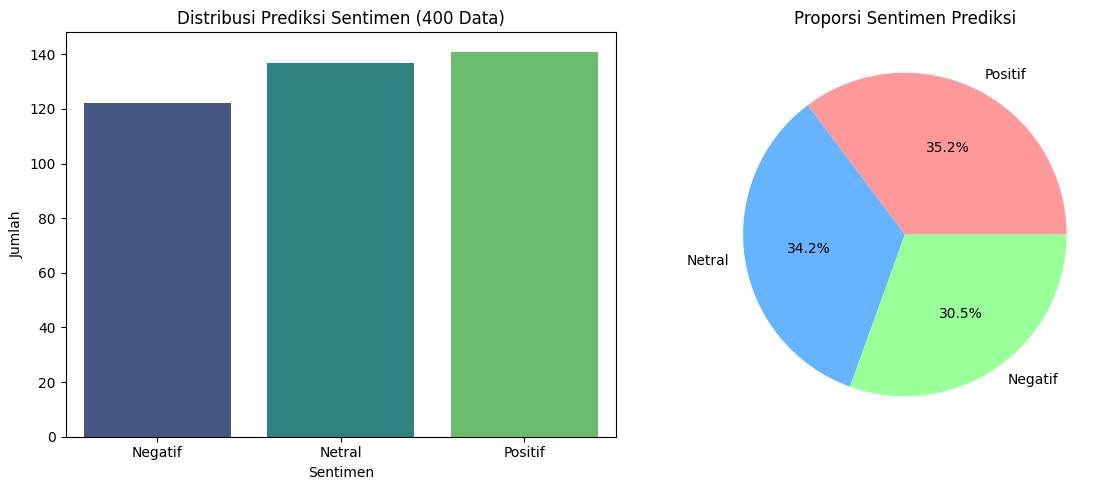


Hasil telah disimpan ke 'hasil_pelabelan_sentimen.csv'


In [7]:
plt.figure(figsize=(12, 5))

# Plot 1: Distribusi Label Hasil Prediksi
plt.subplot(1, 2, 1)
sns.countplot(data=df_test, x='predicted_label', palette='viridis', order=['Negatif', 'Netral', 'Positif'])
plt.title('Distribusi Prediksi Sentimen (400 Data)')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')

# Plot 2: Persentase Sentimen
plt.subplot(1, 2, 2)
df_test['predicted_label'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Proporsi Sentimen Prediksi')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Simpan hasil ke CSV
df_test.to_csv('hasil_pelabelan_sentimen.csv', index=False)
print("\nHasil telah disimpan ke 'hasil_pelabelan_sentimen.csv'")